frame.drop
frame.sort_index
frame.sort_value

In [2]:
import pandas as pd
%matplotlib inline

DATA_FOLDER = 'Data/'

HAPPINESS_DATASET = DATA_FOLDER+"happiness2020.csv"
COUNTRIES_DATASET = DATA_FOLDER+"countries_info.csv"

In [3]:
# Write your code here
happiness_data = pd.read_csv(HAPPINESS_DATASET)
countries_data = pd.read_csv(COUNTRIES_DATASET, delimiter=',')
print(happiness_data.head())
print(countries_data.head())
print(countries_data.iloc[:,0])

       country  happiness_score  social_support  healthy_life_expectancy  \
0  Afghanistan           2.5669        0.470367                52.590000   
1      Albania           4.8827        0.671070                68.708138   
2      Algeria           5.0051        0.803385                65.905174   
3    Argentina           5.9747        0.900568                68.803802   
4      Armenia           4.6768        0.757479                66.750656   

   freedom_of_choices  generosity  perception_of_corruption  \
0            0.396573   -0.096429                  0.933687   
1            0.781994   -0.042309                  0.896304   
2            0.466611   -0.121105                  0.735485   
3            0.831132   -0.194914                  0.842010   
4            0.712018   -0.138780                  0.773545   

                         world_region  
0                          South Asia  
1          Central and Eastern Europe  
2        Middle East and North Africa  
3   

In [4]:
#选几个列可以用
#data = df[[df['column_name'].isin(['value1', 'value2'])]]

In [5]:
# Write your code here
happiness_data['country_name'] = happiness_data['country'].apply(lambda x : x.lower()) #apply是逐元素操作？
happiness_data = happiness_data.drop('country', axis=1) #axis 删除列；删除行的话直接用index
country_features = happiness_data.merge(countries_data, on='country_name')
country_features.head()
#怎么调整列顺序

,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,country_name,area,population,literacy
0,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia,afghanistan,647500,31056997,"36,0"
1,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe,albania,28748,3581655,"86,5"
2,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa,algeria,2381740,32930091,"70,0"
3,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean,argentina,2766890,39921833,"97,1"
4,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States,armenia,29800,2976372,"98,6"


In [6]:
# drop: 用于删除DataFrame中的指定行或列。例如，假设我们有一个DataFrame df：
# df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6], 'C': [7, 8, 9]})
# 如果我们想删除列 'B'，可以使用 df.drop(columns=['B'])，结果如下：
#     A  C
# 0  1  7
# 1  2  8
# 2  3  9

# sort_index: 用于根据索引对DataFrame进行排序。例如，假设我们有一个DataFrame df：
# df = pd.DataFrame({'A': [1, 2, 3]}, index=[2, 0, 1])
# 如果我们想根据索引排序，可以使用 df.sort_index()，结果如下：
#    A
# 0  2
# 1  3
# 2  1

# sort_values: 用于根据指定列的值对DataFrame进行排序。例如，假设我们有一个DataFrame df：
# df = pd.DataFrame({'A': [1, 3, 2], 'B': [4, 6, 5]})
# 如果我们想根据列 'A' 的值进行排序，可以使用 df.sort_values(by='A')，结果如下：
#    A  B
# 0  1  4
# 2  2  5
# 1  3  6


In [7]:
# groupby: 用于根据一个或多个列对DataFrame进行分组。例如，假设我们有一个DataFrame df：
# df = pd.DataFrame({'A': ['foo', 'bar', 'foo', 'bar'], 'B': [1, 2, 3, 4]})
# 如果我们想根据列 'A' 进行分组，可以使用 df.groupby('A')，结果如下：
# <pandas.core.groupby.generic.DataFrameGroupBy object at 0x...>

# agg: 用于对分组后的数据进行聚合操作。以下是一些常见的聚合指令：
# - mean: 计算平均值
# - sum: 计算总和
# - max: 计算最大值
# - min: 计算最小值
# - count: 计算非NA/null值的数量
# - median: 计算中位数
# - std: 计算标准差
# - var: 计算方差

# 下面是一个例子，展示了如何对不同的列进行不同的聚合操作：
df = pd.DataFrame({
    'A': ['foo', 'bar', 'foo', 'bar'],
    'B': [1, 2, 3, 4],
    'C': [5, 6, 7, 8]
})

# 我们可以对列 'B' 求平均值，对列 'C' 求最大值：
result = df.groupby('A').agg({'B': ['mean', 'std'], 'C': 'max'})
print(result)
# 结果如下：
#          B           C
#       mean       std  max
# A                           
# bar    3.0  1.414214    8
# foo    2.0  1.414214    7
result = df.groupby('A').agg(
    B_mean = ('B','mean'), 
    B_max = ('B','max'),
    C_max = ('C','max')
)
print(result)
#只有一列，可以直接call agg中的函数；size是对group名操作；其余是对数据列
average_by_region = happiness_data.groupby("world_region")['happiness_score'].agg(['mean','size','var','max'])
average_by_region.sort_values("mean", ascending=False)
#有多列，要指定操作列和函数
# Write your code here
region_data = happiness_data.groupby('world_region').agg(
    {
        'happiness_score': 'mean',  # 对'happiness_score'列计算平均值
        'country_name': 'count'
    }
)

#groupby之后生成的frame index是 group的那个feature

       B             C
    mean       std max
A                     
bar  3.0  1.414214   8
foo  2.0  1.414214   7
     B_mean  B_max  C_max
A                        
bar     3.0      4      8
foo     2.0      3      7


In [8]:
# 假设原始的列顺序如下

print(country_features.columns)

# 重新排列列的顺序
new_column_order = [
    'country_name', 'world_region', 'happiness_score', 'social_support',
    'healthy_life_expectancy', 'freedom_of_choices', 'generosity',
    'perception_of_corruption', 'area', 'population', 'literacy'
]

# 使用新的列顺序创建一个新的DataFrame
country_features = country_features[new_column_order]

# 打印新的列顺序
print(country_features.head())

Index(['happiness_score', 'social_support', 'healthy_life_expectancy',
       'freedom_of_choices', 'generosity', 'perception_of_corruption',
       'world_region', 'country_name', 'area', 'population', 'literacy'],
      dtype='object')
  country_name                        world_region  happiness_score  \
0  afghanistan                          South Asia           2.5669   
1      albania          Central and Eastern Europe           4.8827   
2      algeria        Middle East and North Africa           5.0051   
3    argentina         Latin America and Caribbean           5.9747   
4      armenia  Commonwealth of Independent States           4.6768   

   social_support  healthy_life_expectancy  freedom_of_choices  generosity  \
0        0.470367                52.590000            0.396573   -0.096429   
1        0.671070                68.708138            0.781994   -0.042309   
2        0.803385                65.905174            0.466611   -0.121105   
3        0.900568      

In [9]:
# Write your code here
literacy_features = country_features[["country_name", "literacy", "country_name"]]
literacy_features.head()
print(literacy_features['literacy']==100)
#用==得到的是由布尔组成的新frame

0      False
1      False
2      False
3      False
4      False
       ...  
130    False
131    False
132    False
133    False
134    False
Name: literacy, Length: 135, dtype: bool


In [10]:
for index, row in literacy_features.iterrows():
    print(index, row)
    print(row['literacy'])
    break
#逐列迭代

0 country_name    afghanistan
literacy               36,0
country_name    afghanistan
Name: 0, dtype: object
36,0


In [11]:
import pandas as pd
#loc和iloc的用法 loc是label，iloc是index
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Score': [85, 90, 95]
}
df = pd.DataFrame(data, index=['a', 'b', 'c'])

print(df)

print("Element at row 'a', column 'Name':", df.loc['a', 'Name'])

print(df.loc['b'])

print(df.loc['a':'c', ['Name', 'Score']])

print("Element at row 0, column 0:", df.iloc[0, 0])

print(df.iloc[1])

print(df.iloc[0:2, 1:3])

print("Using loc: Rows 'a' to 'b' (inclusive):")
print(df.loc['a':'b'])

print("Using iloc: Rows 0 to 1 (exclusive of end):")
print(df.iloc[0:2])


      Name  Age  Score
a    Alice   25     85
b      Bob   30     90
c  Charlie   35     95
Element at row 'a', column 'Name': Alice
Name     Bob
Age       30
Score     90
Name: b, dtype: object
      Name  Score
a    Alice     85
b      Bob     90
c  Charlie     95
Element at row 0, column 0: Alice
Name     Bob
Age       30
Score     90
Name: b, dtype: object
   Age  Score
a   25     85
b   30     90
Using loc: Rows 'a' to 'b' (inclusive):
    Name  Age  Score
a  Alice   25     85
b    Bob   30     90
Using iloc: Rows 0 to 1 (exclusive of end):
    Name  Age  Score
a  Alice   25     85
b    Bob   30     90


<Axes: title={'center': 'Bar Plot'}, xlabel='Category'>

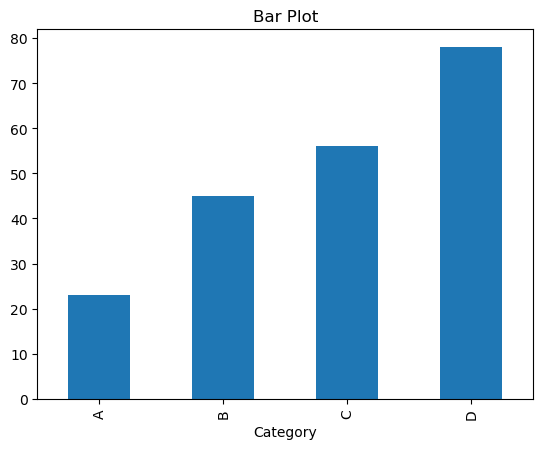

In [13]:
import pandas as pd
import numpy as np

# 示例数据
data = {'Category': ['A', 'B', 'C', 'D'],
        'Values': [23, 45, 56, 78]}
df = pd.DataFrame(data)

# 绘制柱状图
df.plot(kind='bar', x='Category', y='Values', title="Bar Plot", legend=False)


<Axes: title={'center': 'Horizontal Bar Plot'}, ylabel='Category'>

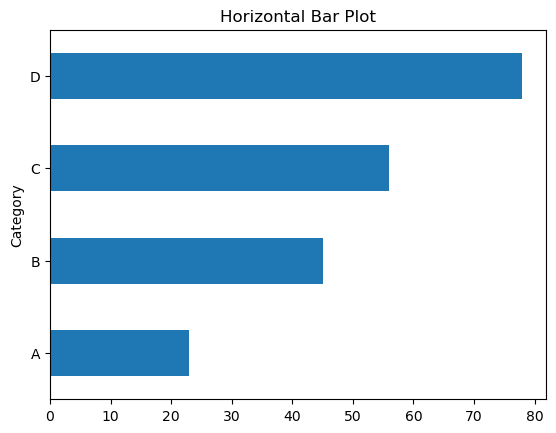

In [14]:
# 水平柱状图
df.plot(kind='barh', x='Category', y='Values', title="Horizontal Bar Plot", legend=False)


<Axes: title={'center': 'Line Plot'}, xlabel='Month'>

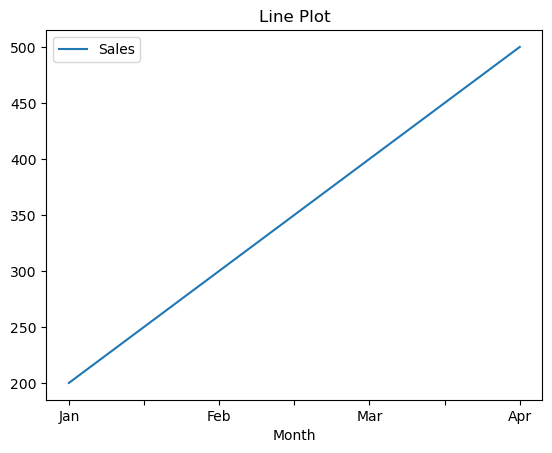

In [15]:
# 创建时间序列数据
df_line = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr'],
    'Sales': [200, 300, 400, 500]
})

# 折线图
df_line.plot(kind='line', x='Month', y='Sales', title="Line Plot")


<Axes: title={'center': 'Density Plot'}, ylabel='Density'>

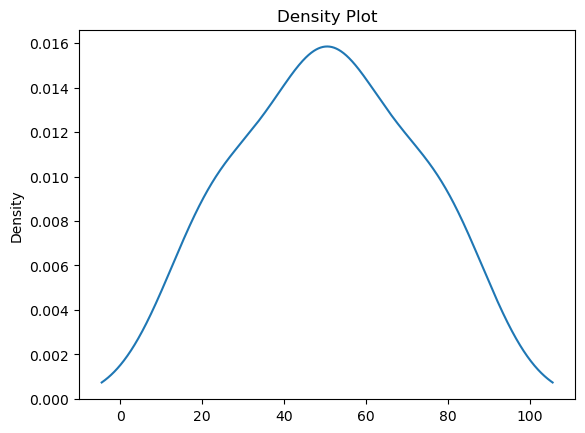

In [16]:
# 密度图
df_hist = pd.DataFrame({
    'Values': [23, 45, 56, 78, 23, 45, 56, 78, 23, 45, 56, 78]
})
df_hist.plot(kind='kde', y='Values', title="Density Plot", legend=False)


<Axes: title={'center': 'Pie Chart'}, ylabel='Values'>

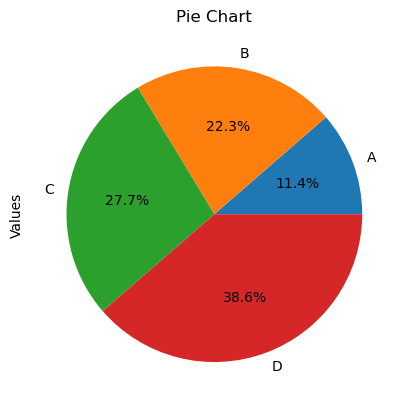

In [17]:
# 饼图
df.plot(kind='pie', y='Values', labels=df['Category'], autopct='%1.1f%%', title="Pie Chart", legend=False)


<Axes: title={'center': 'Box Plot'}>

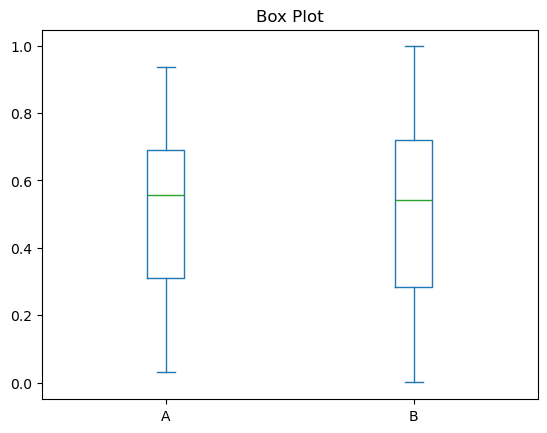

In [18]:
# 创建数据
df_box = pd.DataFrame({
    'A': np.random.rand(50),
    'B': np.random.rand(50)
})

# 箱线图
df_box.plot(kind='box', title="Box Plot")


<Axes: title={'center': 'Area Plot'}, xlabel='Year'>

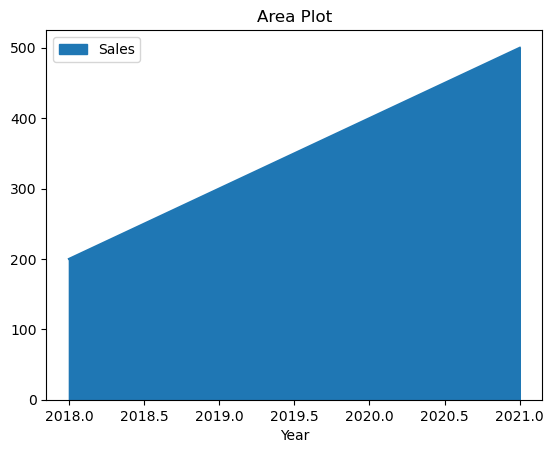

In [19]:
# 面积图
df_area = pd.DataFrame({
    'Year': [2018, 2019, 2020, 2021],
    'Sales': [200, 300, 400, 500]
}).set_index('Year')

df_area.plot(kind='area', title="Area Plot")


<Axes: title={'center': 'Stacked Bar Plot'}>

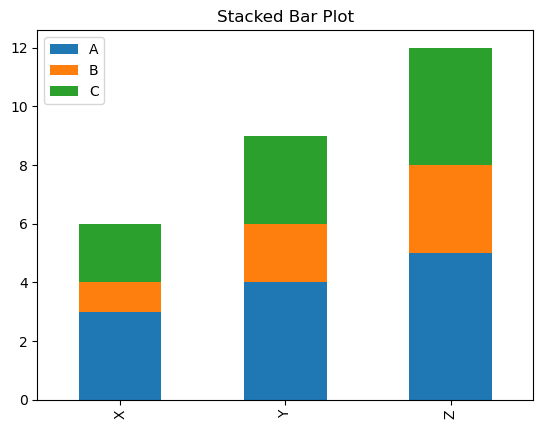

In [20]:
# 创建数据
df_stacked = pd.DataFrame({
    'A': [3, 4, 5],
    'B': [1, 2, 3],
    'C': [2, 3, 4]
}, index=['X', 'Y', 'Z'])

# 堆叠柱状图
df_stacked.plot(kind='bar', stacked=True, title="Stacked Bar Plot")
